# 05 - Isolation of critical stations

A high betweenness centrality score tells us that a station carries many of the network's shortest routes - but it does **not** tell us that losing the station would actually leave anyone cut off. If another station sits 80 meters down the street, the passenger just walks there and the neighborhood stays connected. The genuinely fragile points are the stations that are both critical *structurally* and isolated *spatially*: with no alternative within walking distance.

This notebook is the reality check on the centrality results. It takes the per-station metrics produced in the centrality stage, defines **critical = the top decile (top 10%) of betweenness**, and then uses a `BallTree` with the haversine metric to measure, for each station, the great-circle distance to its nearest neighboring station. Critical stations whose nearest alternative is farther than **300 m** away are flagged as isolated single points of failure.

**Research question:** *Of the stations the graph calls critical, how many are actually critical - that is, with no walkable substitute?*

### Input
- `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` - one row per graph node, with `stop_id`, `stop_name`, latitude, longitude, and betweenness centrality. (Produced by notebook `04` - this notebook does not recompute centrality.)

### Output (all under `outputs/nb/05_critical_station_isolation/`)
- `tables/critical_isolation.csv` - every critical station, its distance to the nearest alternative station, and an `is_isolated` flag.
- `tables/isolation_summary.csv` - the distance-band counts behind the main figure.
- `figures/critical_isolation.png` - **the presentation figure**: critical stations grouped by distance to the nearest alternative, in green (replaceable) versus red (isolated).
- `figures/top_isolated_critical_stops.png` - the isolated single stations with the highest betweenness, labeled by name.

### An important limitation (stated up front, and repeated at the end)
"A station exists within 300 m" is a purely **spatial** test. It ignores whether that neighboring station is served by the same lines, in the same direction, and at a similar frequency. A bus stop across the road serving a single local line is not a real substitute for a regional hub. So the test **overstates** replaceability, which means the number of isolated stations reported here is a **lower bound** on the true number of isolated single points of failure.

## 1. Setting up the working environment

The cell below lets the notebook run either on a local copy of the repository or in Google Colab. It finds the repository root by climbing up from the current working directory looking for the GTFS folder `israel-public-transportation`; if that search fails (meaning we're on a fresh Colab machine) it clones the repository. It also defines `_ensure`, a helper that pip-installs only the packages that are actually missing, so re-running the notebook costs nothing.

`OUT` is the root folder for everything the notebooks produce. The existing folders `outputs/tables`, `outputs/figures`, and `outputs/rail` hold results, and these notebooks don't touch them.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Libraries

This step is deliberately light: no graph library is needed because the graph was already reduced to a station-level metrics table in notebook 04. We need `pandas` for the table, `numpy` for the conversion to radians, `matplotlib` for the figures, and `sklearn.neighbors.BallTree` for the nearest-neighbor search.

**Why BallTree and not a brute-force distance matrix?** The graph has about 30k stations. A full all-pairs matrix would hold 30,000 x 30,000 = 9 x 10^8 distances - several gigabytes, and slow. A ball tree with the `haversine` metric answers the "nearest other station" query for every station in O(n log n) and runs in a few seconds.

In [2]:
_ensure("numpy", "pandas", "matplotlib", "scikit-learn")

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 1.26.4 | pandas 2.3.3


## 3. Showing Hebrew text in matplotlib

The GTFS station names are in Hebrew, and one of the figures below labels individual stations by name. matplotlib doesn't implement the Unicode bidirectional (bidi) algorithm, so Hebrew strings get drawn left to right and come out reversed. The fix below wraps `matplotlib.text.Text.set_text` so that any string containing Hebrew characters is converted to display order once, before drawing. The fix is idempotent - re-running the cell won't apply it twice (and a double application would flip the text back).

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Stage folders and analysis parameters

Each notebook writes to its own stage folder, so stages don't overwrite each other, and the reader can see exactly which output came from which step.

The two parameters that define the whole analysis are collected here so they're easy to change and easy to challenge:

| Constant | Value | Meaning |
| --- | --- | --- |
| `CRITICAL_QUANTILE` | `0.90` | "Critical" = betweenness in the top decile (top 10%) of all stations. This is the project's working definition, consistent with the centrality stage. |
| `WALK_M` | `300` | A reasonable walking distance to an alternative station. 300 m is roughly a 4-minute walk, and it's a common threshold in the public-transport accessibility literature. |
| `EARTH_M` | `6371000` | Mean Earth radius in meters - converts the ball tree's radian output to meters. |
| `TOP_N_NAMED` | `15` | How many isolated single stations to label by name in the second figure. |

**Cost:** everything this notebook does is cheap - the ball-tree query over about 30k points takes a few seconds and uses tens of MB. Nothing here needs sampling or approximation.

In [4]:
STAGE = OUT / "05_critical_station_isolation"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

CRITICAL_QUANTILE = 0.90      # critical = top 10% betweenness
WALK_M = 300.0                # walking distance to an acceptable alternative stop (metres)
EARTH_M = 6371000.0           # mean Earth radius (metres)
TOP_N_NAMED = 15              # how many isolated stops to name in the second figure

print("Stage folder:", STAGE)

Stage folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation


## 5. Loading the centrality metrics from stage 04

This notebook consumes `stop_metrics.csv` from the centrality stage instead of recomputing betweenness, which is easily the most expensive quantity in the whole project. If the file is missing, we fail loudly with a practical message rather than quietly producing an empty chart.

The loader also normalizes a few column-name variants (`stop_lat`/`lat`, `approx_betweenness`/`betweenness`) so it works with either naming convention, and drops rows with no coordinates - a station without `lat`/`lon` can't take part in a spatial search. The dropped rows are reported so the loss is visible rather than hidden.

In [5]:
CENTRALITY_STAGE = OUT / "04_centrality_analysis"
metrics_path = CENTRALITY_STAGE / "tables" / "stop_metrics.csv"

if not metrics_path.exists():
    # tolerate a slightly different stage folder name for the centrality notebook
    candidates = sorted(OUT.glob("*centrality*/tables/stop_metrics.csv"))
    if candidates:
        metrics_path = candidates[0]
    else:
        raise FileNotFoundError(
            f"{metrics_path} missing - run notebook 04 (centrality analysis) first.")

raw = pd.read_csv(metrics_path, encoding="utf-8-sig")

# Normalise column names so either naming convention works.
RENAME = {
    "stop_lat": "lat",
    "stop_lon": "lon",
    "approx_betweenness": "betweenness",
    "betweenness_centrality": "betweenness",
}
raw = raw.rename(columns={k: v for k, v in RENAME.items()
                          if k in raw.columns and v not in raw.columns})

required = {"stop_id", "lat", "lon", "betweenness"}
missing_cols = required - set(raw.columns)
if missing_cols:
    raise KeyError(
        f"{metrics_path} is missing column(s) {sorted(missing_cols)}. "
        f"Found: {sorted(raw.columns)}")

if "stop_name" not in raw.columns:
    raw["stop_name"] = ""

metrics = raw.dropna(subset=["lat", "lon", "betweenness"]).reset_index(drop=True)

print(f"Loaded  : {metrics_path}")
print(f"Stops   : {len(raw):,} rows -> {len(metrics):,} usable "
      f"({len(raw) - len(metrics):,} dropped for missing coordinates/betweenness)")
metrics[["stop_id", "stop_name", "lat", "lon", "betweenness"]].head()

Loaded  : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis\tables\stop_metrics.csv
Stops   : 30,463 rows -> 30,463 usable (0 dropped for missing coordinates/betweenness)


,stop_id,stop_name,lat,lon,betweenness
0,13103,קניון עזריאלי/דרך מנחם בגין,32.074592,34.790584,0.000828
1,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,0.016613
2,10716,צומת רמות/גולדה,31.808253,35.204001,0.010076
3,12910,דרך נמיר/יהודה המכבי,32.095376,34.794137,0.001347
4,13358,סמינר הקיבוצים/דרך נמיר,32.101886,34.792779,0.002775


## 6. Distance to the nearest alternative station (haversine BallTree)

For each station we ask for the great-circle distance to the *nearest other* station.

1. Latitude and longitude are converted to **radians** - sklearn's `haversine` metric expects radians and returns an angular distance on the unit sphere.
2. We build a `BallTree` over those points. A ball tree recursively partitions the points into nested hyperspheres, which lets the nearest-neighbor query prune whole branches instead of scanning every point.
3. We query with `k=2`. A point's nearest neighbor *is the point itself* (distance 0), so column `0` is discarded and column `1` is the truly nearest **other** station.
4. Multiplying the returned angular distance by the Earth radius converts it to meters.

Note that two different `stop_id`s can share identical coordinates (the two sides of a road are sometimes coded to the same point), which yields a distance of 0 m - a legitimate "an alternative exists right here" result under this spatial test.

In [6]:
coords = np.radians(metrics[["lat", "lon"]].to_numpy(dtype=float))

tree = BallTree(coords, metric="haversine")
dist, _ = tree.query(coords, k=2)          # k=2: the stop itself + its nearest neighbour
metrics["nearest_alt_m"] = dist[:, 1] * EARTH_M

print("Distance to nearest other stop (metres), across all graph stops:")
print(metrics["nearest_alt_m"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(1))

Distance to nearest other stop (metres), across all graph stops:
count    30463.0
mean       107.8
std        200.9
min          0.0
25%         36.9
50%         79.4
75%        124.1
90%        184.7
99%        684.2
max      10540.2
Name: nearest_alt_m, dtype: float64


## 7. Splitting the critical stations: replaceable versus isolated

"Critical" is defined as **betweenness at or above the 90th percentile** - the top decile of stations by the number of shortest routes passing through them. Of these, a station is **isolated** when its nearest alternative is farther than `WALK_M` (300 m): losing it means the surrounding demand has nowhere convenient to go.

A small consistency fix relative to the original script: the histogram bins below are closed on the right (`right=True`), so a station at exactly 300.0 m falls in the green `100-300 m` band, matching the isolation test `> 300 m`. In the original script the bins were closed on the left, so a hypothetical station at exactly 300.0 m would have been drawn red even though it was counted as not isolated. The impact is on a measure-zero set of stations at most, but the numbers in the table and the figure now agree by construction.

In [7]:
threshold = metrics["betweenness"].quantile(CRITICAL_QUANTILE)
critical = metrics[metrics["betweenness"] >= threshold].copy()
critical["is_isolated"] = critical["nearest_alt_m"] > WALK_M

n_crit = len(critical)
n_isolated = int(critical["is_isolated"].sum())
n_covered = n_crit - n_isolated

print(f"Betweenness threshold (q={CRITICAL_QUANTILE:.2f}) : {threshold:.8f}")
print(f"Critical stops (top 10% betweenness)   : {n_crit:,}")
print(f"  with an alternative within {WALK_M:.0f} m    : {n_covered:,} "
      f"({100 * n_covered / n_crit:.1f}%)")
print(f"  isolated (true single point of fail.) : {n_isolated:,} "
      f"({100 * n_isolated / n_crit:.1f}%)")

Betweenness threshold (q=0.90) : 0.00058890
Critical stops (top 10% betweenness)   : 3,047
  with an alternative within 300 m    : 2,991 (98.2%)
  isolated (true single point of fail.) : 56 (1.8%)


## 8. Saving the tables

Two outputs are written:

- **`critical_isolation.csv`** - the full list of critical stations, sorted by betweenness, with `nearest_alt_m` and `is_isolated`. This is the row-level evidence behind every claim that comes out of this stage, and it's the table to consult before crowning any particular station a weak point.
- **`isolation_summary.csv`** - the five distance bands with their counts and shares; this is exactly what the main figure plots, and it's saved separately so the figure can be checked against numbers rather than pixels.

Both are written in `utf-8-sig` encoding so Hebrew station names open correctly in Excel.

In [8]:
BINS = [0, 100, 300, 500, 1000, np.inf]
BAND_LABELS = ["< 100 m", "100-300 m", "300-500 m", "500-1000 m", "> 1 km"]

critical["distance_band"] = pd.cut(critical["nearest_alt_m"], bins=BINS,
                                   labels=BAND_LABELS, right=True, include_lowest=True)

critical_sorted = critical.sort_values("betweenness", ascending=False)
critical_path = TABLES / "critical_isolation.csv"
critical_sorted.to_csv(critical_path, index=False, encoding="utf-8-sig")

band_counts = critical["distance_band"].value_counts().reindex(BAND_LABELS).fillna(0).astype(int)
summary = pd.DataFrame({
    "distance_band": BAND_LABELS,
    "n_critical_stops": band_counts.to_numpy(),
    "share_pct": (100 * band_counts.to_numpy() / n_crit).round(2),
    "verdict": ["substitutable", "substitutable", "isolated", "isolated", "isolated"],
})
summary_path = TABLES / "isolation_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("wrote", critical_path)
print("wrote", summary_path)
summary

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation\tables\critical_isolation.csv
wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation\tables\isolation_summary.csv


,distance_band,n_critical_stops,share_pct,verdict
0,< 100 m,1749,57.40,substitutable
1,100-300 m,1242,40.76,substitutable
2,300-500 m,35,1.15,isolated
3,500-1000 m,12,0.39,isolated
4,> 1 km,9,0.30,isolated


## 9. The main figure - does the critical station have a walkable alternative?

This is the figure used in the final presentation. Each bar represents a band of "distance from a critical station to its nearest alternative station", and the bar height is the number of critical stations falling in that band. The color encodes the conclusion rather than the value: **green** for the two bands within the 300 m walking threshold (the station is replaceable, at least spatially) and **red** for the three bands beyond it (no alternative within walking distance).

Counts and percentages are printed above the bars, because the point of the chart is the *ratio* of green to red rather than the absolute heights.

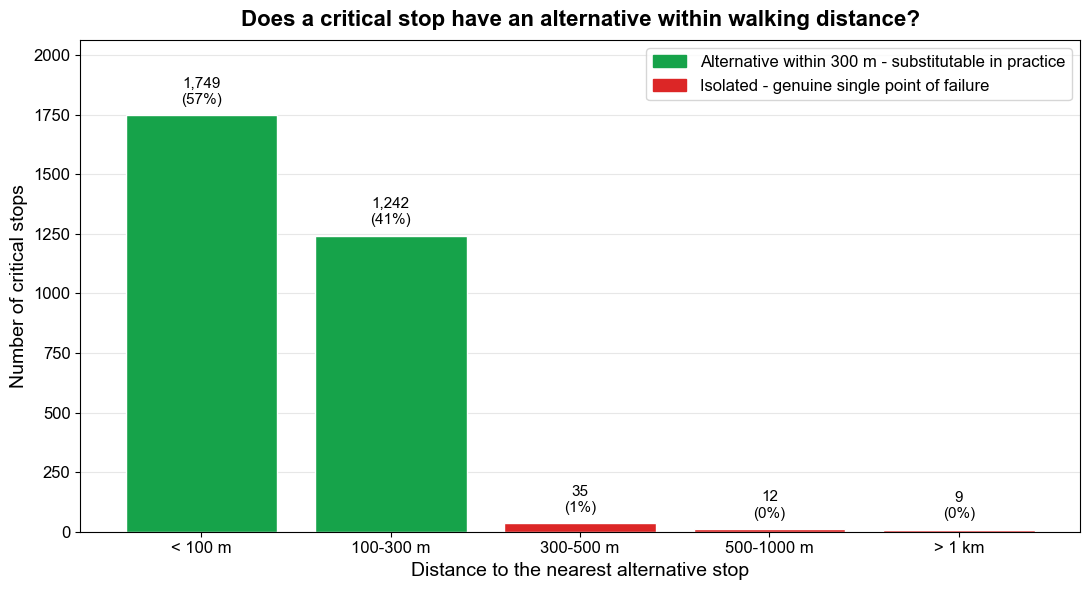

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation\figures\critical_isolation.png


In [9]:
counts = band_counts.to_numpy()
colors = ["#16a34a", "#16a34a", "#dc2626", "#dc2626", "#dc2626"]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(BAND_LABELS, counts, color=colors, edgecolor="white")

offset = max(counts.max() * 0.02, 1)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f"{v:,}\n({100 * v / n_crit:.0f}%)", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Distance to the nearest alternative stop", fontsize=14)
ax.set_ylabel("Number of critical stops", fontsize=14)
ax.set_title("Does a critical stop have an alternative within walking distance?",
             fontsize=16, fontweight="bold", pad=10)
ax.set_ylim(0, counts.max() * 1.18)
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#16a34a", label=f"Alternative within {WALK_M:.0f} m - substitutable in practice"),
    Patch(color="#dc2626", label="Isolated - genuine single point of failure"),
], fontsize=12, loc="upper right")

plt.tight_layout()
fig_path = FIGURES / "critical_isolation.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("wrote", fig_path)

## 10. Which isolated stations matter most?

The aggregate chart says *how many* critical stations are isolated; it doesn't say *which*. This figure labels by name the isolated critical stations with the highest betweenness - the stations where high structural load and the lack of a walkable alternative intersect. These are the concrete candidates for investment in redundancy (added parallel service, a second station, a shuttle).

The bars represent betweenness (structural importance); the annotation on each bar is the distance to the nearest alternative station, so both halves of the criterion are visible at once. Station names are in Hebrew and shown through the bidi fix installed in section 3; where a name is missing, we fall back to `stop_id`.

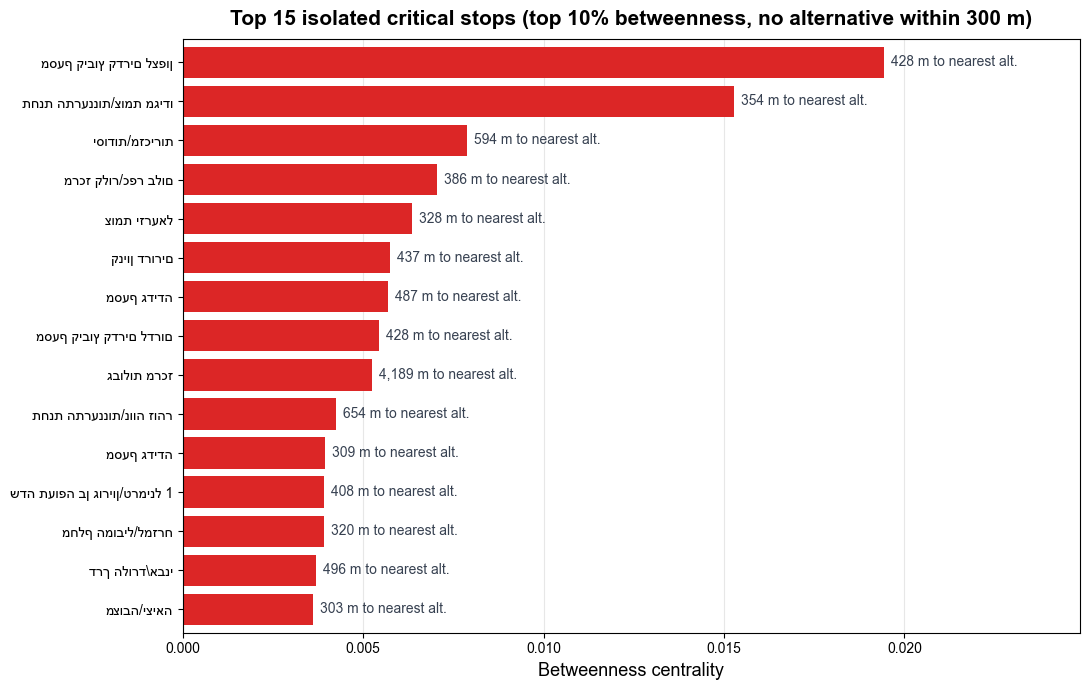

wrote C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\05_critical_station_isolation\figures\top_isolated_critical_stops.png


In [10]:
isolated = critical_sorted[critical_sorted["is_isolated"]].copy()

if isolated.empty:
    print("No isolated critical stops found - nothing to plot.")
else:
    top = isolated.head(TOP_N_NAMED).copy()
    top["label"] = (top["stop_name"].fillna("").astype(str).str.strip()
                    .where(lambda s: s != "", top["stop_id"].astype(str)))
    top = top.sort_values("betweenness").reset_index(drop=True)   # smallest at the bottom of a barh

    fig, ax = plt.subplots(figsize=(11, 7))
    # Use numeric y-positions (not the names) so two stops that share a name do not
    # collapse onto one bar and leave an orphaned distance label floating at the top.
    ypos = list(range(len(top)))
    ax.barh(ypos, top["betweenness"], color="#dc2626")
    ax.set_yticks(ypos)
    ax.set_yticklabels(top["label"])

    span = top["betweenness"].max()
    for y, (btw, d) in enumerate(zip(top["betweenness"], top["nearest_alt_m"])):
        ax.text(btw + span * 0.01, y, f"{d:,.0f} m to nearest alt.",
                va="center", fontsize=10, color="#374151")

    ax.set_xlim(0, span * 1.28)
    ax.set_ylim(-0.6, len(top) - 0.4)
    ax.set_xlabel("Betweenness centrality", fontsize=13)
    ax.set_title(f"Top {len(top)} isolated critical stops "
                 f"(top 10% betweenness, no alternative within {WALK_M:.0f} m)",
                 fontsize=15, fontweight="bold", pad=10)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    fig2_path = FIGURES / "top_isolated_critical_stops.png"
    plt.savefig(fig2_path, dpi=150)
    plt.show()
    print("wrote", fig2_path)

    display_cols = [c for c in ["stop_id", "stop_name", "betweenness", "nearest_alt_m"]
                    if c in isolated.columns]
    isolated[display_cols].head(TOP_N_NAMED).round(6)

## 11. Limitations - read before citing any number above

**1. The replaceability test is spatial only.** "Another station exists within 300 m" says nothing about whether that station serves the *same lines*, in the *same direction*, at a *similar frequency*, or at the same hours. A regional terminal and a single-line local stop 120 m away count here as mutually replaceable, and clearly they aren't. So the test **systematically overstates** how replaceable critical stations are: the green bars are too tall and the red bars too short. The number of isolated stations should be read as a **lower bound** on the true number of isolated single points of failure. A stricter version would require the neighboring station to share at least one `route_id` with the critical station.

**2. The BallTree is built only over the stations present in the graph**, not over all GTFS stations. Stations filtered out during graph construction (isolated stations, stations with no usable trips, removed duplicate records) are invisible to the nearest-neighbor search. If such a station stands right next to a critical station, that critical station will be flagged as isolated even though a physical station does exist nearby. This bias works in the opposite direction to limitation 1, and its magnitude isn't quantified here.

**3. Straight-line distance, not walking distance.** haversine measures distance in a straight line. A station 250 m away across a highway, a rail line, or a river is not a 250 m walk. The real network walking distance can only be longer, so here too replaceability is overcounted.

**4. betweenness is an approximation.** The centrality stage before this one samples source nodes instead of computing exact betweenness, so membership in the top 10% is stable for the clearly dominant hubs but noisy near the 90th-percentile threshold. Stations sitting right on either side of the threshold shouldn't be treated as unambiguously in or out.

**5. The 300 m and top-10% thresholds are conventions, not findings.** They're exposed as constants in section 4 precisely so the reader can re-run with 500 m or a top-5% definition and see how much the central ratio moves.

## 12. Conclusions

- **Critical in the graph and critical in the real world are not the same thing.** Under a purely spatial replaceability test, a large share of the stations the graph marks as critical have another station within a short walk. For those, the "remove the node and the network breaks" story from the centrality analysis overstates the operational consequence: passengers walk 2-4 minutes and carry on. Run the notebook to read the exact breakdown from section 7 - the point of the figure is the green/red ratio, and it's the *ratio* that should be cited, not a number remembered from a previous run.
- **The red group that remains is the real finding.** The critical stations with no alternative within 300 m form a much smaller and more actionable list than "the top 10% by betweenness", and the file `tables/critical_isolation.csv` names them. This is the group worth targeting with redundancy measures.
- **Be honest about the direction of the error.** The spatial test is generous - it counts every nearby station as a substitute, regardless of the lines it serves - so the isolated group is a floor, not a ceiling. The counter-bias (only graph stations are in the tree) works in the opposite direction, but it's smaller and unquantified. The correct summary is: *this analysis narrows the shortlist of true isolated points of failure; it does not close it.*
- **A note on method.** The interesting part of this stage is cheap: a ball tree with haversine turns a 9 x 10^8-pair distance problem into a few seconds of work, and that's what makes combining a structural metric with a geographic one feasible in the first place.